In [1]:
import pandas as pd

avgHouseholdSize = pd.read_csv('avg-household-size.csv')
cancerRegression = pd.read_csv('cancer-regression.csv')

cancerDataset = pd.merge(avgHouseholdSize, cancerRegression, on='geography') 
print(f'cancer dataset shape: {cancerDataset.shape}')
cancerDataset.head()


cancer dataset shape: (3047, 36)


,statefips,countyfips,avghouseholdsize,geography,avganncount,avgdeathsperyear,target_deathrate,incidencerate,medincome,popest2015,...,pctprivatecoveragealone,pctempprivcoverage,pctpubliccoverage,pctpubliccoveragealone,pctwhite,pctblack,pctasian,pctotherrace,pctmarriedhouseholds,birthrate
0,2,16,3.59,"Aleutians West Census Area, Alaska",8.0,3,203.3,201.3,68387,5702,...,60.4,58.3,11.2,6.2,31.562280,4.732583,37.156932,5.295567,42.882250,4.391052
1,2,20,2.77,"Anchorage Municipality, Alaska",1085.0,352,167.5,453.3,75200,298695,...,NaN,45.9,24.5,12.9,64.944652,5.854427,8.800530,1.747201,48.361303,5.994294
2,2,50,3.86,"Bethel Census Area, Alaska",37.0,20,218.8,338.2,45808,17946,...,25.8,25.1,47.3,36.1,12.016202,0.798830,1.175743,0.343159,45.521390,9.156280
3,2,70,3.56,"Dillingham Census Area, Alaska",16.0,7,216.6,409.2,51082,4997,...,29.1,28.6,41.2,30.2,18.718618,0.341434,1.446074,0.482025,46.478873,11.801242
4,2,90,2.69,"Fairbanks North Star Borough, Alaska",307.0,105,177.2,424.4,67801,99631,...,59.8,43.9,22.2,10.4,76.649115,4.352841,2.628755,0.891630,50.354112,7.382578


In [2]:
features = cancerDataset.drop(labels=['target_deathrate', 'binnedinc'], axis=1)
target = cancerDataset['target_deathrate']

# preserve the state name and use it as a categorical feature
features['state'] = features['geography'].str.split(', ').str[1]
features = features.drop('geography', axis=1)
features.head()

,statefips,countyfips,avghouseholdsize,avganncount,avgdeathsperyear,incidencerate,medincome,popest2015,povertypercent,studypercap,...,pctempprivcoverage,pctpubliccoverage,pctpubliccoveragealone,pctwhite,pctblack,pctasian,pctotherrace,pctmarriedhouseholds,birthrate,state
0,2,16,3.59,8.0,3,201.3,68387,5702,9.9,0.00000,...,58.3,11.2,6.2,31.562280,4.732583,37.156932,5.295567,42.882250,4.391052,Alaska
1,2,20,2.77,1085.0,352,453.3,75200,298695,10.0,565.79454,...,45.9,24.5,12.9,64.944652,5.854427,8.800530,1.747201,48.361303,5.994294,Alaska
2,2,50,3.86,37.0,20,338.2,45808,17946,23.8,0.00000,...,25.1,47.3,36.1,12.016202,0.798830,1.175743,0.343159,45.521390,9.156280,Alaska
3,2,70,3.56,16.0,7,409.2,51082,4997,17.5,0.00000,...,28.6,41.2,30.2,18.718618,0.341434,1.446074,0.482025,46.478873,11.801242,Alaska
4,2,90,2.69,307.0,105,424.4,67801,99631,9.5,270.99999,...,43.9,22.2,10.4,76.649115,4.352841,2.628755,0.891630,50.354112,7.382578,Alaska


In [3]:
# Descriptive statistics
print("=" * 60)
print("FEATURES STATISTICS")
print("=" * 60)
print(features.describe())

print("\n" + "=" * 60)
print("TARGET STATISTICS")
print("=" * 60)
print(target.describe())

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)
print(f"Features missing values:\n{features.isnull().sum()}")
print(f"\nTarget missing values: {target.isnull().sum()}")

FEATURES STATISTICS
         statefips   countyfips  avghouseholdsize   avganncount  \
count  3047.000000  3047.000000       3047.000000   3047.000000   
mean     30.272071   101.802429          2.529682    606.338544   
std      15.054873   104.315612          0.248449   1416.356223   
min       1.000000     1.000000          1.860000      6.000000   
25%      19.000000    35.000000          2.380000     76.000000   
50%      29.000000    79.000000          2.500000    171.000000   
75%      45.000000   133.000000          2.640000    518.000000   
max      56.000000   840.000000          3.970000  38150.000000   

       avgdeathsperyear  incidencerate      medincome    popest2015  \
count       3047.000000    3047.000000    3047.000000  3.047000e+03   
mean         185.965868     448.268586   47063.281917  1.026374e+05   
std          504.134286      54.560733   12040.090836  3.290592e+05   
min            3.000000     201.300000   22640.000000  8.270000e+02   
25%           28.0000

## Feature engineering experiments
Create a few derived features from insurance, education, employment, and income, then compare performance on the original and engineered feature sets.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# ===== HANDLE MISSING VALUES =====
print("=" * 60)
print("BEFORE IMPUTATION")
print("=" * 60)
print(f"Missing values per column:\n{features.isnull().sum()[features.isnull().sum() > 0]}")
print(f"\nTotal missing values: {features.isnull().sum().sum()}")

# Impute missing values with median (robust to outliers)
imputer = SimpleImputer(strategy='median')
features_imputed = pd.DataFrame(imputer.fit_transform(features), columns=features.columns)

print("\n" + "=" * 60)
print("AFTER IMPUTATION")
print("=" * 60)
print(f"Missing values: {features_imputed.isnull().sum().sum()}")

# ===== SPLIT DATA BEFORE SCALING =====
# Important: Split BEFORE scaling to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    features_imputed, target, test_size=0.2, random_state=42
)

print(f"\nTraining set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

# ===== SCALE FEATURES =====
# StandardScaler: mean=0, std=1 (best for most algorithms)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), 
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("\n" + "=" * 60)
print("AFTER SCALING (Training Set)")
print("=" * 60)
print(X_train_scaled.describe())

BEFORE IMPUTATION
Missing values per column:
pctsomecol18_24            2285
pctemployed16_over          152
pctprivatecoveragealone     609
dtype: int64

Total missing values: 3046


ValueError: Cannot use median strategy with non-numeric data:
could not convert string to float: 'Alaska'

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def errorCalculation(y_test, y_pred, modelName):
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print("\n" + "=" * 60)
    print(f"{modelName} PERFORMANCE")
    print("=" * 60)
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"Mean Absolute Error: {mae:.2f}")
    print(f"R^2 Score: {r2:.4f}")
    print(f"RMSE: {mse**0.5:.2f}")
    


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Reuse or define the error helper
if 'errorCalculation' not in globals():
    def errorCalculation(y_test, y_pred, modelName):
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print("\n" + "=" * 60)
        print(f"{modelName} PERFORMANCE")
        print("=" * 60)
        print(f"Mean Squared Error: {mse:.2f}")
        print(f"Mean Absolute Error: {mae:.2f}")
        print(f"R^2 Score: {r2:.4f}")
        print(f"RMSE: {mse**0.5:.2f}")

if 'X_train_scaled' not in globals() or 'y_train' not in globals():
    imputer = SimpleImputer(strategy='median')
    features_imputed = pd.DataFrame(imputer.fit_transform(features), columns=features.columns)
    X_train, X_test, y_train, y_test = train_test_split(
        features_imputed, target, test_size=0.2, random_state=42
    )
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train),
        columns=X_train.columns,
        index=X_train.index
    )
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test),
        columns=X_test.columns,
        index=X_test.index
    )

features_fe = features.copy()
features_fe['pub_vs_priv'] = features_fe['pctpubliccoverage'] - features_fe['pctprivatecoverage']
features_fe['public_to_private_ratio'] = features_fe['pctpubliccoverage'] / (features_fe['pctprivatecoverage'] + 1e-3)
features_fe['education_ratio'] = features_fe['pctbachdeg25_over'] / (features_fe['pcths25_over'] + 1e-3)
features_fe['employment_ratio'] = features_fe['pctemployed16_over'] / (features_fe['pctunemployed16_over'] + 1e-3)
features_fe['age_diff'] = features_fe['medianagemale'] - features_fe['medianagefemale']
features_fe['poverty_income'] = features_fe['povertypercent'] / (features_fe['medincome'] + 1e-3) * 1000

features_fe = features_fe.replace([np.inf, -np.inf], np.nan).fillna(0)

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    features_fe, target, test_size=0.2, random_state=42
)

scaler_fe = StandardScaler()
X_train_fe_scaled = pd.DataFrame(
    scaler_fe.fit_transform(X_train_fe),
    columns=X_train_fe.columns,
    index=X_train_fe.index
)
X_test_fe_scaled = pd.DataFrame(
    scaler_fe.transform(X_test_fe),
    columns=X_test_fe.columns,
    index=X_test_fe.index
)

print(f"Engineered features: {features_fe.shape[1]}")
print(features_fe[[
    'pub_vs_priv', 'public_to_private_ratio', 'education_ratio',
    'employment_ratio', 'age_diff', 'poverty_income'
]].head())

from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor

baseline_ridge = Ridge()
baseline_ridge.fit(X_train_scaled, y_train)
baseline_pred = baseline_ridge.predict(X_test_scaled)
print("\nBaseline Ridge on original features")
errorCalculation(y_test, baseline_pred, "Ridge (Baseline)")

engineered_ridge = Ridge()
engineered_ridge.fit(X_train_fe_scaled, y_train_fe)
engineered_ridge_pred = engineered_ridge.predict(X_test_fe_scaled)
print("\nRidge on engineered features")
errorCalculation(y_test_fe, engineered_ridge_pred, "Ridge (Engineered)")

boosted = GradientBoostingRegressor(random_state=42)
boosted.fit(X_train_fe_scaled, y_train_fe)
boosted_pred = boosted.predict(X_test_fe_scaled)
print("\nGradient Boosting on engineered features")
errorCalculation(y_test_fe, boosted_pred, "GradientBoosting (Engineered)")


Engineered features: 87
   pub_vs_priv  public_to_private_ratio  education_ratio  employment_ratio  \
0        -57.9                 0.162082         0.278371         38.124703   
1        -45.0                 0.352513         0.867184          0.000000   
2         12.1                 1.343712         0.174308          2.937333   
3          4.4                 1.119535         0.286082          4.151668   
4        -52.8                 0.295996         0.841844          7.619289   

   age_diff  poverty_income  
0       5.9        0.144764  
1      -1.7        0.132979  
2       0.5        0.519560  
3       2.5        0.342586  
4      -1.7        0.140116  

Baseline Ridge on original features

Ridge (Baseline) PERFORMANCE
Mean Squared Error: 391.08
Mean Absolute Error: 13.99
R^2 Score: 0.4740
RMSE: 19.78

Ridge on engineered features

Ridge (Engineered) PERFORMANCE
Mean Squared Error: 389.81
Mean Absolute Error: 13.96
R^2 Score: 0.4757
RMSE: 19.74

Gradient Boosting on engineer

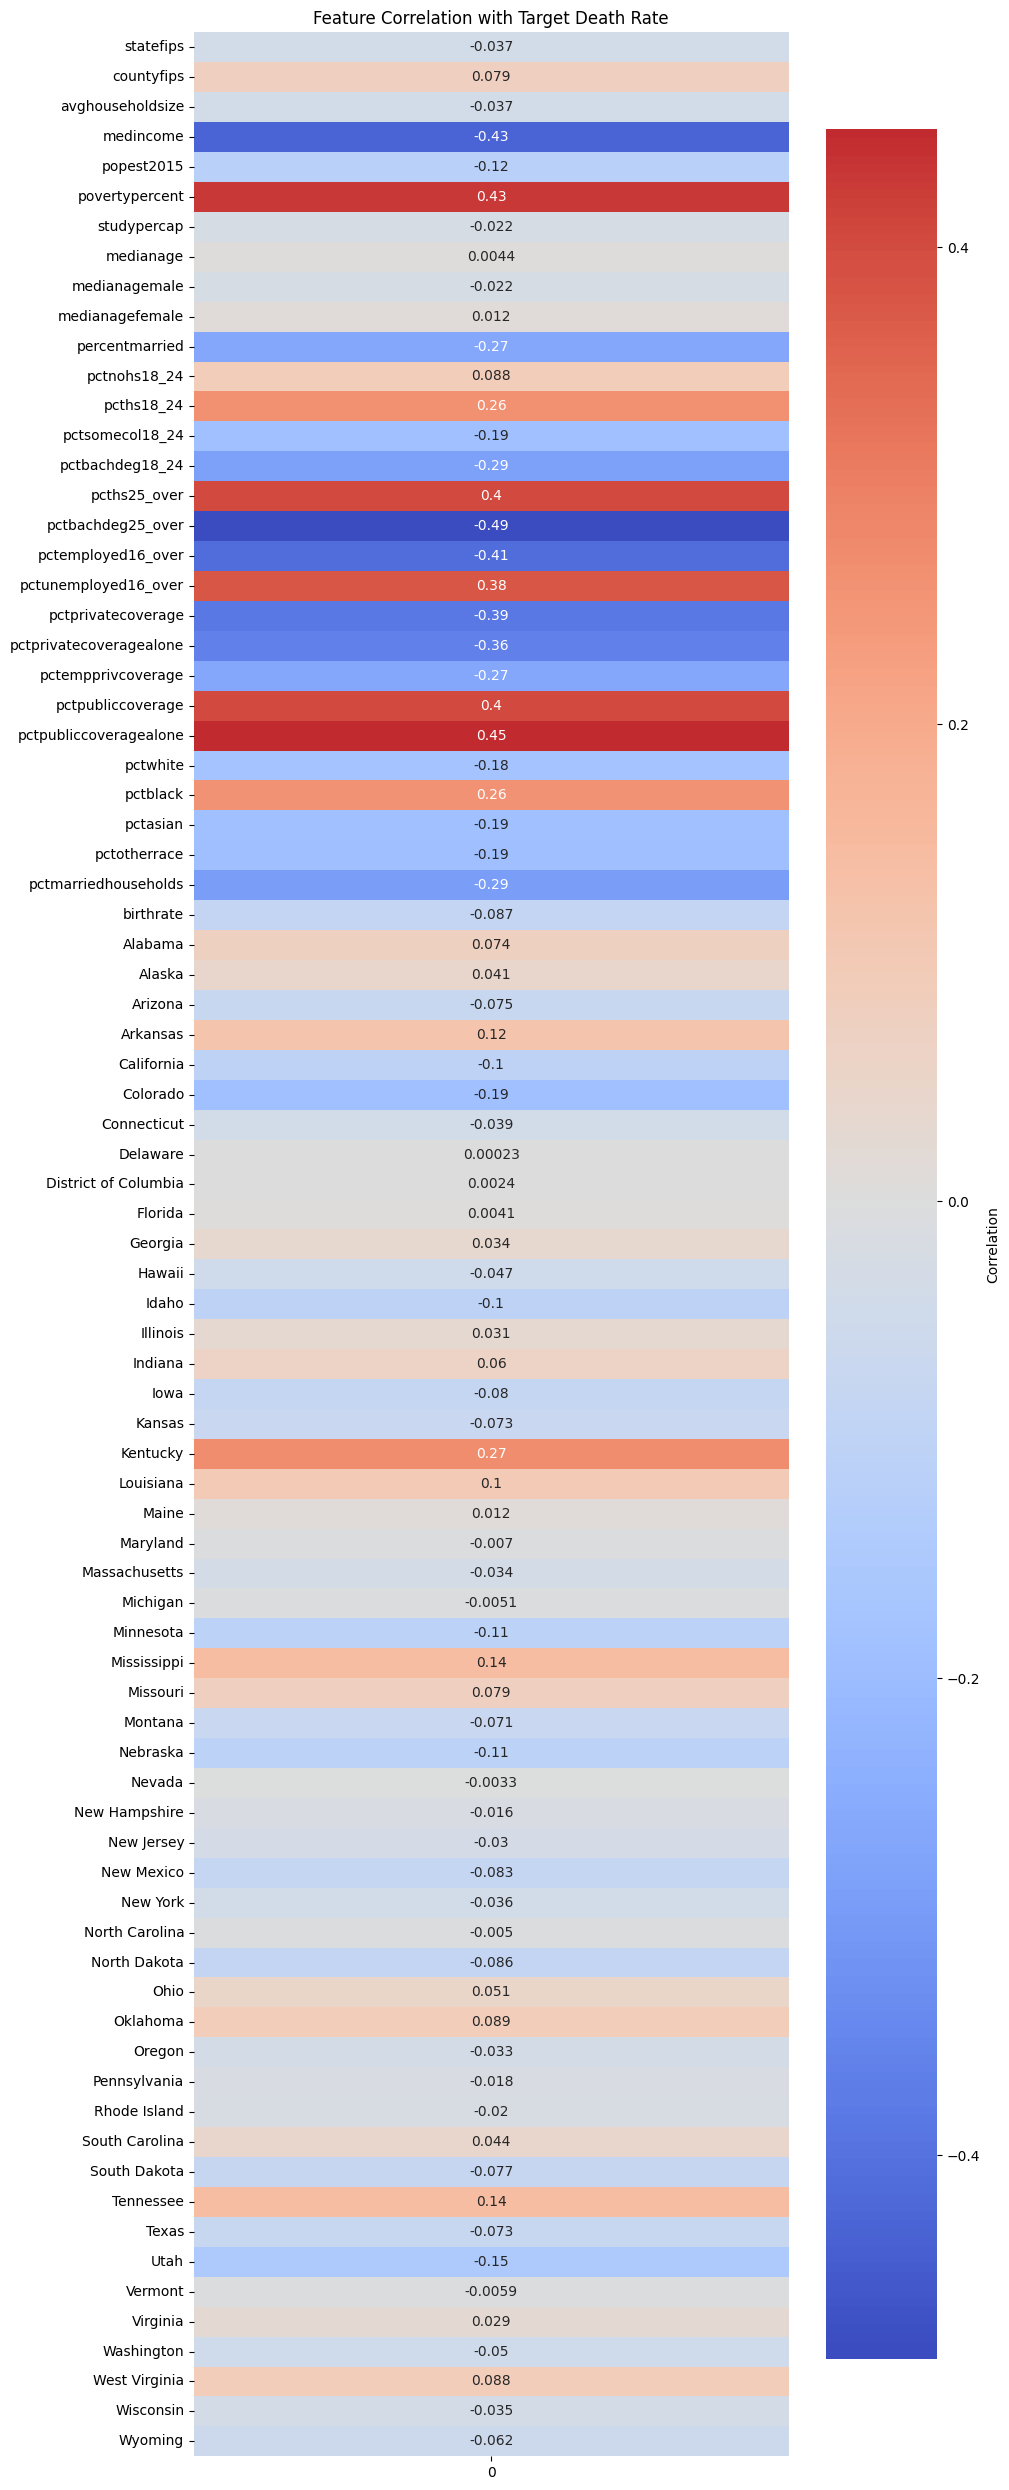

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Feature-to-target correlation heatmap
plt.figure(figsize=(10, 25))
sns.heatmap(features.corrwith(target).to_frame(), annot=True, cmap='coolwarm', center=0, cbar_kws={'label': 'Correlation'})
plt.title('Feature Correlation with Target Death Rate')
plt.tight_layout()
plt.show()

It seems that pctpubliccoverage (percentage of population covered by public health insurance) had the strongest positive correlation to target death rate due to cancer while pctbachdeg25_over (percentage of bachelor's degree holders at least 25 years old) had the strongest negative correlation.

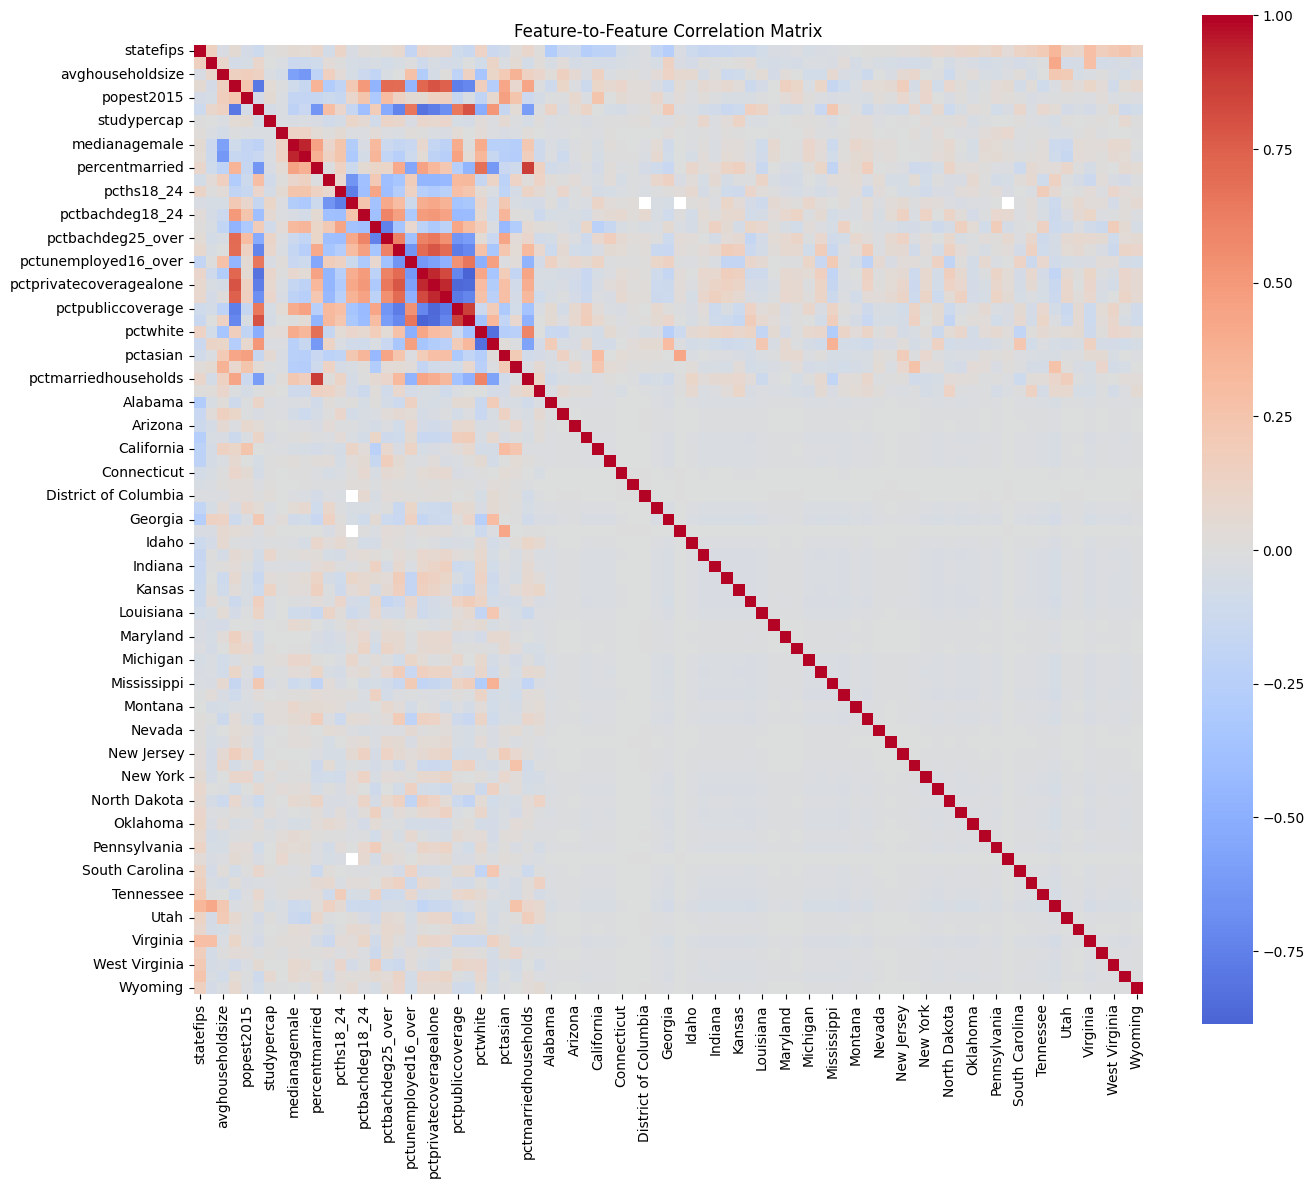

In [ ]:
# Feature-to-feature correlation heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(features.corr(), annot=False, cmap='coolwarm', center=0, square=True)
plt.title('Feature-to-Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# ===== HANDLE MISSING VALUES =====
print("=" * 60)
print("BEFORE IMPUTATION")
print("=" * 60)
print(f"Missing values per column:\n{features.isnull().sum()[features.isnull().sum() > 0]}")
print(f"\nTotal missing values: {features.isnull().sum().sum()}")

# Impute missing values with median (robust to outliers)
imputer = SimpleImputer(strategy='median')
features_imputed = pd.DataFrame(imputer.fit_transform(features), columns=features.columns)

print("\n" + "=" * 60)
print("AFTER IMPUTATION")
print("=" * 60)
print(f"Missing values: {features_imputed.isnull().sum().sum()}")

# ===== SPLIT DATA BEFORE SCALING =====
# Important: Split BEFORE scaling to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    features_imputed, target, test_size=0.2, random_state=42
)

print(f"\nTraining set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

# ===== SCALE FEATURES =====
# StandardScaler: mean=0, std=1 (best for most algorithms)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), 
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("\n" + "=" * 60)
print("AFTER SCALING (Training Set)")
print("=" * 60)
print(X_train_scaled.describe())

BEFORE IMPUTATION
Missing values per column:
pctsomecol18_24            2285
pctemployed16_over          152
pctprivatecoveragealone     609
dtype: int64

Total missing values: 3046

AFTER IMPUTATION
Missing values: 0

Training set size: (2437, 81)
Test set size: (610, 81)

AFTER SCALING (Training Set)
          statefips    countyfips  avghouseholdsize     medincome  \
count  2.437000e+03  2.437000e+03      2.437000e+03  2.437000e+03   
mean   1.107945e-16  2.478298e-17      4.869127e-16  3.010404e-16   
std    1.000205e+00  1.000205e+00      1.000205e+00  1.000205e+00   
min   -1.965563e+00 -9.747980e-01     -2.667491e+00 -2.079285e+00   
25%   -7.630333e-01 -6.445821e-01     -6.307133e-01 -6.873363e-01   
50%   -9.496111e-02 -2.269562e-01     -1.115347e-01 -1.540427e-01   
75%    9.739544e-01  3.072166e-01      4.475808e-01  4.591853e-01   
max    1.708834e+00  7.173764e+00      5.759177e+00  5.235563e+00   

         popest2015  povertypercent   studypercap     medianage  \
count  

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def errorCalculation(y_test, y_pred, modelName):
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print("\n" + "=" * 60)
    print(f"{modelName} PERFORMANCE")
    print("=" * 60)
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"Mean Absolute Error: {mae:.2f}")
    print(f"R^2 Score: {r2:.4f}")
    print(f"RMSE: {mse**0.5:.2f}")
    


In [ ]:
from sklearn import linear_model

linearModel = linear_model.LinearRegression()
linearModel.fit(X_train_scaled, y_train)
y_pred = linearModel.predict(X_test_scaled)
errorCalculation(y_test, y_pred, "Linear Regression")


Linear Regression PERFORMANCE
Mean Squared Error: 391.31
Mean Absolute Error: 13.99
R^2 Score: 0.4737
RMSE: 19.78


In [ ]:
from sklearn.ensemble import RandomForestRegressor
randomForestModel = RandomForestRegressor(n_estimators=100, random_state=42)
randomForestModel.fit(X_train_scaled, y_train)
randomForest_pred = randomForestModel.predict(X_test_scaled)

errorCalculation(y_test, randomForest_pred, "Random Forest")


Random Forest PERFORMANCE
Mean Squared Error: 408.05
Mean Absolute Error: 14.21
R^2 Score: 0.4511
RMSE: 20.20


## Compare other regression families

We can compare several model families on the same preprocessed data. If a non-linear regressor improves significantly, that suggests model-family choice matters. If not, then the dataset and features may be the limiting factor.

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt

# Build a richer feature matrix from the existing inputs
features_model = features.copy()
features_model['pub_vs_priv'] = features_model['pctpubliccoverage'] - features_model['pctprivatecoverage']
features_model['public_to_private_ratio'] = features_model['pctpubliccoverage'] / (features_model['pctprivatecoverage'] + 1e-3)
features_model['education_ratio'] = features_model['pctbachdeg25_over'] / (features_model['pcths25_over'] + 1e-3)
features_model['employment_ratio'] = features_model['pctemployed16_over'] / (features_model['pctunemployed16_over'] + 1e-3)
features_model['age_diff'] = features_model['medianagemale'] - features_model['medianagefemale']
features_model['poverty_income'] = features_model['povertypercent'] / (features_model['medincome'] + 1e-3) * 1000
features_model = features_model.replace([np.inf, -np.inf], np.nan).fillna(0)

X_train_model, X_test_model, y_train_model, y_test_model = train_test_split(
    features_model, target, test_size=0.2, random_state=42
)

categorical_features = ['state']
numerical_features = [col for col in features_model.columns if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numerical_features),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_features),
    ]
)

models = [
    ('RidgeCV', RidgeCV(alphas=[0.001, 0.01, 0.1, 1.0, 10.0, 100.0])),
    ('LassoCV', LassoCV(cv=5, random_state=42, max_iter=20000)),
    ('ElasticNetCV', ElasticNetCV(cv=5, random_state=42, max_iter=20000)),
    ('GradientBoosting', GradientBoostingRegressor(random_state=42))
]

print(f"{'Model':20s} {'R2':>6s} {'RMSE':>8s} {'MAE':>8s}")
for name, model in models:
    pipe = Pipeline([('preprocess', preprocessor), ('model', model)])
    pipe.fit(X_train_model, y_train_model)
    y_pred = pipe.predict(X_test_model)
    mse = mean_squared_error(y_test_model, y_pred)
    mae = mean_absolute_error(y_test_model, y_pred)
    rmse = sqrt(mse)
    print(f"{name:20s} {r2_score(y_test_model, y_pred):6.4f} {rmse:8.2f} {mae:8.2f}")

Model                    R2     RMSE      MAE
Ridge                0.4740    19.78    13.99
Lasso                0.4520    20.18    14.56
ElasticNet           0.4478    20.26    14.54
GradientBoosting     0.4613    20.01    14.08
HistGradientBoosting 0.4372    20.45    14.28
SVR                  0.3756    21.55    15.31


In [ ]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 10, 15, 20, 25, 30],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 3, 4, 6, 8],
    'max_features': ['sqrt', 'log2', 0.25, 0.5, 0.75, None],
    'bootstrap': [True, False]
}

rf = RandomForestRegressor(random_state=42)
rand_search = RandomizedSearchCV(
    rf,
    param_dist,
    n_iter=24,
    cv=4,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
rand_search.fit(X_train_scaled, y_train)

print("\n" + "=" * 60)
print("STAGE 1: RANDOMIZED SEARCH BEST")
print("=" * 60)
print(rand_search.best_params_)
print(f"Best CV R^2: {rand_search.best_score_:.4f}")

best_params = rand_search.best_params_
max_features_values = [best_params['max_features']]
if isinstance(best_params['max_features'], float):
    mf = best_params['max_features']
    max_features_values = [max(0.1, mf - 0.2), mf, min(1.0, mf + 0.2)]

grid_params = {
    'n_estimators': [max(100, best_params['n_estimators'] - 100), best_params['n_estimators'], best_params['n_estimators'] + 100],
    'max_depth': [best_params['max_depth'], None] if best_params['max_depth'] is not None else [None, 10, 15],
    'min_samples_split': [max(2, best_params['min_samples_split'] - 2), best_params['min_samples_split'], best_params['min_samples_split'] + 2],
    'min_samples_leaf': [max(1, best_params['min_samples_leaf'] - 1), best_params['min_samples_leaf'], best_params['min_samples_leaf'] + 1],
    'max_features': max_features_values,
    'bootstrap': [best_params['bootstrap']]
}

print("\n" + "=" * 60)
print("STAGE 2: GRID SEARCH PARAMETERS")
print("=" * 60)
print(grid_params)

grid_search = GridSearchCV(
    rf,
    grid_params,
    cv=4,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_scaled, y_train)

print("\n" + "=" * 60)
print("STAGE 2: GRID SEARCH BEST")
print("=" * 60)
print(grid_search.best_params_)
print(f"Best CV R^2: {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_
best_rf_pred = best_rf.predict(X_test_scaled)
errorCalculation(y_test, best_rf_pred, "Random Forest (Tuned)")

Fitting 4 folds for each of 24 candidates, totalling 96 fits

STAGE 1: RANDOMIZED SEARCH BEST
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.25, 'max_depth': 15, 'bootstrap': True}
Best CV R^2: 0.4485

STAGE 2: GRID SEARCH PARAMETERS
{'n_estimators': [100, 100, 200], 'max_depth': [15, None], 'min_samples_split': [3, 5, 7], 'min_samples_leaf': [1, 1, 2], 'max_features': [0.1, 0.25, 0.45], 'bootstrap': [True]}
Fitting 4 folds for each of 162 candidates, totalling 648 fits

STAGE 2: GRID SEARCH BEST
{'bootstrap': True, 'max_depth': None, 'max_features': 0.25, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best CV R^2: 0.4509

Random Forest (Tuned) PERFORMANCE
Mean Squared Error: 410.29
Mean Absolute Error: 14.22
R^2 Score: 0.4481
RMSE: 20.26
